## 1 Create the training and validation datasets
### 1.1 Load the data


In [1]:
import pickle

# Load professor's training data
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    training_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    expected_heights = pickle.load(f)

# Add HW4 data
with open('/workspace/Homework/Project1/HW-4-n_k_m_P', 'rb') as f:
    training_data += pickle.load(f)
with open('/workspace/Homework/Project1/HW-4-mHeights', 'rb') as f:
    expected_heights += pickle.load(f)

# 80/20 training/validation split
from sklearn.model_selection import train_test_split
train_data, val_data, train_heights, val_heights = train_test_split(
    training_data, expected_heights, test_size=0.2, random_state=42)

### 1.2 Pre-process the data
n=9
k is in [4,5,6]
m is in [2,..,n-k]

So we have 9 combinations for n,k,m
1 n = 9 , k = 4 , m = 2
2. n = 9 , k = 4 , m = 3
3. n = 9 , k = 4 , m = 4
4. n = 9 , k = 4 , m = 5
5. n = 9 , k = 5 , m = 2
6. n = 9 , k = 5 , m = 3
7. n = 9 , k = 5 , m = 4
8. n = 9 , k = 6 , m = 2
9. n = 9 , k = 6 , m = 3

P is a 2-dimensional numpy array of k rows and n-k columns

We need to normalize and convert this data into a single tensor of 37 dimensions (3 for k values + 4 for m values + 30 for P)

In [2]:
#We need to convert the training data into a format suitable for our algorithm. Assuming the training data is in the form of a list of tuples (n, k, m, P), we can extract the features and labels as follows:
#Normalize the values in P (from -100 to 100) to be between 0 and 1
#Because n is always 9, we can ignore it as a feature
import numpy as np
import tensorflow as tf

#K can be 4, 5, or 6 for our case
def one_hot_encode_k(k):
    if k == 4:
        return [1, 0, 0]
    elif k == 5:
        return [0, 1, 0]
    elif k == 6:
        return [0, 0, 1]
    else:
        raise ValueError("Invalid value for k: {}".format(k))
#m can be 2-5 for our case    
def one_hot_encode_m(m):
    if m == 2:
        return [1, 0, 0, 0]
    elif m == 3:
        return [0, 1, 0, 0]
    elif m == 4:
        return [0, 0, 1, 0]
    elif m == 5:
        return [0, 0, 0, 1]
    else:
        raise ValueError("Invalid value for m: {}".format(m))

def preprocess_P(P, k, n=9):
    P = (P + 100) / 200.0
    # Pad to max size: 6 rows x 5 cols = 30
    P_pad = np.zeros((6, 5))
    P_pad[:k, :n-k] = P
    return P_pad.flatten()  # always 30 values   

def preprocess_labels(heights):
    # Log transform the heights to make them more suitable for regression
    # In case of log(0) or log of negative numbers, we can add a small constant to the heights before taking the log
    heights = np.array(heights)
    heights = heights + 1e-6  # Add a small constant to avoid log(0)
    heights = np.log(heights)  
    return heights

def preprocess_features(data):
    features = []
    for n, k, m, P in data:
        feat = np.concatenate([one_hot_encode_k(k), one_hot_encode_m(m), preprocess_P(P, k, n)])
        features.append(feat)
    return np.array(features, dtype=np.float32)  # shape: (N, 37)
 
X_train, y_train = preprocess_features(train_data), preprocess_labels(train_heights)
X_val, y_val = preprocess_features(val_data), preprocess_labels(val_heights)

BATCH_SIZE = 256

#Print shapes to verify
print("Training features shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation features shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

#Print sample features and labels to verify
print("Sample training features (first 5):", X_train[:5])
print("Sample training labels (first 5):", y_train[:5])

2026-03-14 18:24:52.509715: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 18:24:52.521327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-14 18:24:52.534007: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-14 18:24:52.537787: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-14 18:24:52.549309: I tensorflow/core/platform/cpu_feature_guar

Training features shape: (78052, 37)
Training labels shape: (78052,)
Validation features shape: (19514, 37)
Validation labels shape: (19514,)
Sample training features (first 5): [[1.    0.    0.    0.    0.    1.    0.    0.54  0.53  0.505 0.51  0.515
  0.5   0.515 0.535 0.525 0.515 0.52  0.53  0.48  0.54  0.505 0.54  0.495
  0.46  0.53  0.485 0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [1.    0.    0.    1.    0.    0.    0.    0.555 0.815 0.33  0.01  0.595
  0.265 0.65  1.    0.33  0.085 0.49  0.175 0.56  0.76  0.61  0.8   0.45
  0.915 0.595 0.745 0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [1.    0.    0.    0.    1.    0.    0.    0.715 0.88  0.015 0.845 0.945
  0.595 0.365 0.555 0.02  0.39  0.55  0.94  0.1   0.04  0.87  0.39  0.64
  0.655 0.18  0.22  0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [1.    0.    0.    1.    0.    0.    0.    0.305 0.195 0.16  0.195 0.87
  0.635 0.855 0.43  0.265 0.645 0.635 0.53  0.42  0.725 0.505 0.245

## 2 Create the models
 * The first input is an integer n.
 * The second input is an integer k.
 *  The third input is an integer m.
 * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
numpy array), which forms the last n k columns of a systematic k ⇥n
generator matrix G.

* The output is a continuous value m-height

### 2.1 Create a basic baseline model

In [3]:
#Create DNN model:
 # * The first input is an integer n - we will ignore this since n is always 9.
#  * The second input is an integer k.
#  *  The third input is an integer m.
#  * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
# numpy array), which forms the last n k columns of a systematic k ⇥n
# generator matrix G.

# * The output is a continuous positive value m-height
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_basic_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    # Don't use ReLU here because we want to allow the model to predict any real value 
    # (log(m-height) can be negative), and we will exponentiate the output later to get m-height
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model

### 2.2 Create a Deeper Neural Network with skip layers and batch normalization

In [4]:
def create_deeper_model():
    inputs = keras.Input(shape=(37,), name='input')
    
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Residual block 1 (256 -> 256)
    skip1 = x
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256)(x)  # no activation before the add
    x = layers.Add()([x, skip1])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Residual block 2 (128 -> 128)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    skip2 = x  # save AFTER projecting to 128
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128)(x)  # no activation before the add
    x = layers.Add()([x, skip2])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.3 Create a model with regularization

In [5]:
def create_regularized_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers with L2 regularization and Dropout
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model

### 2.4 Create a CNN

In [6]:
def create_convolutional_model():
    # Full input: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Split: k/m metadata vs P matrix
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)   # first 7: k + m one-hots
    p_features = layers.Lambda(lambda x: x[:, 7:])(inputs)     # last 30: flattened P

    # Reshape P to (6, 5, 1) for Conv2D
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)

    # Conv layers with small kernels (input is only 6x5)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Concatenate conv features with k/m metadata
    x = layers.Concatenate()([km_features, x])

    # Fully connected layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.5 Create a Mixture of Experts

In [7]:
def create_moe_models():
    """
    Mixture of Experts: train 9 separate models, one per (k, m) combination.
    Each expert only sees the P features (30-dim) since k and m are fixed for that expert.
    Returns a dict mapping (k, m) -> compiled model.
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        inputs = keras.Input(shape=(30,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
        models[(k_val, m_val)] = model
    return models

def train_moe_models(models, X_train, y_train, X_val, y_val, epochs=50, batch_size=4096, callbacks=None):
    """Train each expert on its subset of data. Returns dict of histories."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        # Filter training data for this (k, m)
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask = (X_val[:, k_idx] == 1) & (X_val[:, 3 + m_idx] == 1)
        # Extract only the P features (columns 7:37)
        X_tr = X_train[train_mask, 7:].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v = X_val[val_mask, 7:].astype('float32')
        y_v = y_val[val_mask].astype('float32')
        # Scale batch size to ~1/8 of expert dataset so we get ~8 batches/epoch
        # (avoids the 1-batch-per-epoch problem when global batch_size >> expert dataset)
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nTraining expert for k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, bs={expert_bs}")
        # Build per-expert tf.data datasets
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42)
                 .batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v,
                            epochs=epochs, verbose=1,
                            callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories

def predict_moe(models, X_data):
    """Use the appropriate expert for each sample based on its k/m one-hot encoding."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = model.predict(X_data[mask, 7:], verbose=0).flatten()
    return predictions

### 2.5b Create a CNN Mixture of Experts

In [8]:
_P_INDICES = {
    k: [row * 5 + col for row in range(k) for col in range(9 - k)]
    for k in [4, 5, 6]
}

def create_cnn_moe_models():
    """
    CNN Mixture of Experts: 9 separate CNN models, one per (k, m) combination.
    Each expert uses the native (unpadded) P matrix for its k value:
      k=4 -> 4x5 = 20-dim P  (columns 0..4)
      k=5 -> 5x4 = 20-dim P  (columns 0..3)
      k=6 -> 6x3 = 18-dim P  (columns 0..2)
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        n_rows, n_cols = k_val, 9 - k_val
        p_dim = n_rows * n_cols
        inputs = keras.Input(shape=(p_dim,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Reshape((n_rows, n_cols, 1))(inputs)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
        models[(k_val, m_val)] = model
    return models


def train_cnn_moe_models(models, X_train, y_train, X_val, y_val,
                         epochs=50, batch_size=256, callbacks=None):
    """Train each CNN expert on its own (k, m) subset using native P features."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask   = (X_val[:,   k_idx] == 1) & (X_val[:,   3 + m_idx] == 1)
        col_idx = [7 + i for i in _P_INDICES[k_val]]
        X_tr = X_train[train_mask][:, col_idx].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v  = X_val[val_mask][:, col_idx].astype('float32')
        y_v  = y_val[val_mask].astype('float32')
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nCNN expert k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, "
              f"input_dim={len(col_idx)} ({k_val}x{9-k_val}), bs={expert_bs}")
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42).batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v  = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                 .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v, epochs=epochs, verbose=1, callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories


def predict_cnn_moe(models, X_data):
    """Run each CNN expert on its subset and assemble into a single prediction array."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            col_idx = [7 + i for i in _P_INDICES[k_val]]
            predictions[mask] = model.predict(X_data[mask][:, col_idx], verbose=0).flatten()
    return predictions

## 2.6 Create a NN with custom loss that matches our grading 

In [9]:
# Note: The grading cost is (log2(y) - log2(y_hat))^2.
# Since our targets are ln(y), this equals (ln(y) - ln(y_hat))^2 / ln(2)^2.
# That is just MSE / ln(2)^2, so MSE is already proportional to the grading metric.
# No custom loss needed — standard MSE on log-transformed targets is optimal.
#
# If you still want to see it explicitly:
def log2_mse_loss(y_true, y_pred):
    """Grading-equivalent loss: (log2(y) - log2(y_hat))^2, where inputs are in ln-space."""
    ln2 = tf.cast(tf.math.log(2.0), dtype=y_true.dtype)
    return tf.reduce_mean(tf.square((y_true - y_pred) / ln2))

def create_custom_loss_model():
    inputs = keras.Input(shape=(37,), name='input')
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

### 2.7 CNN with custom log₂ MSE loss
Combines the convolutional architecture (spatial P-matrix processing) with the grading-aligned loss function.

In [10]:
def create_cnn_custom_loss_model():
    """CNN architecture compiled with the grading-aligned log2 MSE loss."""
    inputs = keras.Input(shape=(37,), name='input')
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)
    p_features  = layers.Lambda(lambda x: x[:, 7:])(inputs)
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Concatenate()([km_features, x])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

## 3 Train and compare all models
### 3.1 Basic model

In [11]:
EPOCHS = 500
results = {}  # store (model, history) for each model type

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)

# --- 1. Basic Model ---
print("=" * 60)
print("Training: Basic Model")
print("=" * 60)
basic_model = create_basic_model()
basic_history = basic_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                callbacks=[early_stop],
)
results['Basic'] = (basic_model, basic_history)

Training: Basic Model


I0000 00:00:1773512694.732630  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.809216  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.809292  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.815089  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Epoch 1/500


I0000 00:00:1773512694.815166  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.815234  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.928129  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773512694.928190  279395 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 18:24:54.928201: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.

 24/305 [=>............................] - ETA: 1s - loss: 20.8504 - mae: 3.8245

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


305/305 [==============================] - 3s 6ms/step - loss: 5.0111 - mae: 1.6373 - val_loss: 0.8669 - val_mae: 0.6909
Epoch 2/500
305/305 [==============================] - 2s 5ms/step - loss: 2.3192 - mae: 1.1601 - val_loss: 0.7922 - val_mae: 0.6534
Epoch 3/500
305/305 [==============================] - 2s 5ms/step - loss: 2.0992 - mae: 1.0985 - val_loss: 0.8917 - val_mae: 0.6947
Epoch 4/500
305/305 [==============================] - 2s 6ms/step - loss: 1.9740 - mae: 1.0607 - val_loss: 0.8558 - val_mae: 0.6823
Epoch 5/500
305/305 [==============================] - 2s 6ms/step - loss: 1.8844 - mae: 1.0345 - val_loss: 0.7631 - val_mae: 0.6391
Epoch 6/500
305/305 [==============================] - 2s 6ms/step - loss: 1.8363 - mae: 1.0217 - val_loss: 0.7877 - val_mae: 0.6535
Epoch 7/500
305/305 [==============================] - 2s 6ms/step - loss: 1.7509 - mae: 0.9957 - val_loss: 0.8293 - val_mae: 0.6654
Epoch 8/500
305/305 [==============================] - 2s 6ms/step - loss: 1.6906

### 3.2 Deeper Model

In [12]:
# --- 2. Deeper Model (with residual connections + BatchNorm) ---
print("=" * 60)
print("Training: Deeper Model")
print("=" * 60)
deeper_model = create_deeper_model()
deeper_history = deeper_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                  callbacks=[keras.callbacks.EarlyStopping(
                                      monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Deeper'] = (deeper_model, deeper_history)

Training: Deeper Model
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  9/305 [..............................] - ETA: 3s - loss: 49.9510 - mae: 6.6661 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


305/305 [==============================] - 7s 14ms/step - loss: 5.5398 - mae: 1.6540 - val_loss: 5.5873 - val_mae: 2.1029
Epoch 2/500
305/305 [==============================] - 4s 13ms/step - loss: 1.7318 - mae: 1.0034 - val_loss: 2.1081 - val_mae: 1.2458
Epoch 3/500
305/305 [==============================] - 4s 13ms/step - loss: 1.4090 - mae: 0.8982 - val_loss: 2.2328 - val_mae: 1.3091
Epoch 4/500
305/305 [==============================] - 4s 13ms/step - loss: 1.2335 - mae: 0.8343 - val_loss: 2.3358 - val_mae: 1.3349
Epoch 5/500
305/305 [==============================] - 4s 13ms/step - loss: 1.1402 - mae: 0.7976 - val_loss: 2.0120 - val_mae: 1.2182
Epoch 6/500
305/305 [==============================] - 3s 11ms/step - loss: 1.0686 - mae: 0.7669 - val_loss: 2.0015 - val_mae: 1.2060
Epoch 7/500
305/305 [==============================] - 4s 13ms/step - loss: 1.0035 - mae: 0.7405 - val_loss: 1.5943 - val_mae: 1.0497
Epoch 8/500
305/305 [==============================] - 4s 13ms/step - loss

### 3.3 Regularized Model

In [13]:
print("=" * 60)
print("Training: Regularized Model")
print("=" * 60)
regularized_model = create_regularized_model()
regularized_history = regularized_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                            epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                            callbacks=[keras.callbacks.EarlyStopping(
                                                monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Regularized'] = (regularized_model, regularized_history)

Training: Regularized Model
Epoch 1/500
  1/305 [..............................] - ETA: 4:17 - loss: 46.5814 - mae: 6.4261

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

305/305 [==============================] - 2s 5ms/step - loss: 6.6675 - mae: 1.8396 - val_loss: 1.1083 - val_mae: 0.7254
Epoch 2/500
305/305 [==============================] - 1s 4ms/step - loss: 2.7159 - mae: 1.2194 - val_loss: 1.0150 - val_mae: 0.6861
Epoch 3/500
305/305 [==============================] - 1s 4ms/step - loss: 2.4978 - mae: 1.1640 - val_loss: 0.9376 - val_mae: 0.6587
Epoch 4/500
305/305 [==============================] - 1s 4ms/step - loss: 2.3455 - mae: 1.1275 - val_loss: 0.9740 - val_mae: 0.6800
Epoch 5/500
305/305 [==============================] - 1s 4ms/step - loss: 2.2317 - mae: 1.1006 - val_loss: 1.0422 - val_mae: 0.7157
Epoch 6/500
305/305 [==============================] - 1s 4ms/step - loss: 2.1546 - mae: 1.0785 - val_loss: 0.9944 - val_mae: 0.6977
Epoch 7/500
305/305 [==============================] - 1s 4ms/step - loss: 2.0862 - mae: 1.0612 - val_loss: 0.8747 - val_mae: 0.6383
Epoch 8/500
305/305 [==============================] - 1s 4ms/step - loss: 1.9974

### 3.4 Convolutional Model

In [14]:
print("=" * 60)
print("Training: Convolutional Model")
print("=" * 60)
conv_model = create_convolutional_model()
conv_history = conv_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                              callbacks=[keras.callbacks.EarlyStopping(
                                  monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Convolutional'] = (conv_model, conv_history)

Training: Convolutional Model
Epoch 1/500


W0000 00:00:1773513886.263005  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.283533  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.287330  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.287565  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.287778  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.288998  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.289377  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.296548  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.302259  279567 gp

  1/305 [..............................] - ETA: 6:57 - loss: 44.1317 - mae: 6.2277

W0000 00:00:1773513886.682623  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.682865  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.684273  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.685589  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.695037  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.696034  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.696732  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.696957  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513886.697701  279567 gp

 26/305 [=>............................] - ETA: 1s - loss: 21.6156 - mae: 3.9271

...

305/305 [==============================] - 2s 5ms/step - loss: 1.5989 - mae: 0.9326 - val_loss: 0.7278 - val_mae: 0.6156
Epoch 8/500
 34/305 [==>...........................] - ETA: 1s - loss: 1.5360 - mae: 0.9178

W0000 00:00:1773513898.225845  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.225955  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226002  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226054  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226102  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226145  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226196  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226295  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513898.226429  279573 gp

305/305 [==============================] - 2s 5ms/step - loss: 1.5166 - mae: 0.9093 - val_loss: 0.6569 - val_mae: 0.5737
Epoch 9/500
 35/305 [==>...........................] - ETA: 1s - loss: 1.4324 - mae: 0.8799

W0000 00:00:1773513899.826171  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826290  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826356  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826410  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826450  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826500  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826547  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826678  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773513899.826825  279567 gp

305/305 [==============================] - 1s 3ms/step - loss: 1.4393 - mae: 0.8834 - val_loss: 0.6255 - val_mae: 0.5517
Epoch 10/500
305/305 [==============================] - 2s 5ms/step - loss: 1.3738 - mae: 0.8613 - val_loss: 0.5566 - val_mae: 0.5154
Epoch 11/500
305/305 [==============================] - 2s 5ms/step - loss: 1.3296 - mae: 0.8440 - val_loss: 0.6687 - val_mae: 0.6195
Epoch 12/500
305/305 [==============================] - 2s 5ms/step - loss: 1.2822 - mae: 0.8281 - val_loss: 0.5878 - val_mae: 0.5447
Epoch 13/500
305/305 [==============================] - 2s 5ms/step - loss: 1.2388 - mae: 0.8113 - val_loss: 0.5728 - val_mae: 0.5246
Epoch 14/500
305/305 [==============================] - 2s 5ms/step - loss: 1.1926 - mae: 0.7945 - val_loss: 0.5432 - val_mae: 0.5319
Epoch 15/500
305/305 [==============================] - 2s 5ms/step - loss: 1.1625 - mae: 0.7795 - val_loss: 0.6021 - val_mae: 0.5617
Epoch 16/500
305/305 [==============================] - 2s 5ms/step - loss:

### 3.5 Mixture of Experts

In [15]:
# --- 3.5. Mixture of Experts (9 separate models, one per (k, m)) ---
print("=" * 60)
print("Training: Mixture of Experts (9 experts)")
print("=" * 60)
moe_models = create_moe_models()
moe_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
moe_histories = train_moe_models(moe_models, X_train, y_train, X_val, y_val,
                                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                                 callbacks=[moe_early_stop],
)


Training: Mixture of Experts (9 experts)

Training expert for k=4, m=2 | train=9020, val=2314, bs=256


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

20/36 [===============>..............] - ETA: 0s - loss: 16.3259 - mae: 3.6868

...

60/60 [==============================] - 2s 9ms/step - loss: 24.4277 - mae: 4.5545 - val_loss: 21.5963 - val_mae: 4.5054
Epoch 2/500
60/60 [==============================] - 0s 8ms/step - loss: 9.9217 - mae: 2.6196 - val_loss: 11.0500 - val_mae: 3.0607
Epoch 3/500
60/60 [==============================] - 0s 8ms/step - loss: 6.7082 - mae: 2.0542 - val_loss: 5.0157 - val_mae: 1.8335
Epoch 4/500
60/60 [==============================] - 1s 8ms/step - loss: 5.3575 - mae: 1.8198 - val_loss: 2.6717 - val_mae: 1.3103
Epoch 5/500
60/60 [==============================] - 1s 8ms/step - loss: 4.4894 - mae: 1.6561 - val_loss: 1.8793 - val_mae: 1.1137
Epoch 6/500
60/60 [==============================] - 0s 8ms/step - loss: 4.0543 - mae: 1.5745 - val_loss: 1.4946 - val_mae: 0.9855
Epoch 7/500
60/60 [==============================] - 0s 8ms/step - loss: 3.6963 - mae: 1.5003 - val_loss: 1.2261 - val_mae: 0.8758
Epoch 8/500
60/60 [==============================] - 0s 8ms/step - loss: 3.3693 - mae: 1.436

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 8/35 [=====>........................] - ETA: 0s - loss: 81.6567 - mae: 8.8479 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

35/35 [==============================] - 2s 11ms/step - loss: 68.2565 - mae: 8.0058 - val_loss: 72.4263 - val_mae: 8.3969
Epoch 2/500
35/35 [==============================] - 0s 8ms/step - loss: 37.7509 - mae: 5.6602 - val_loss: 58.2304 - val_mae: 7.4931
Epoch 3/500
35/35 [==============================] - 0s 8ms/step - loss: 20.0451 - mae: 3.7755 - val_loss: 38.6191 - val_mae: 6.0274
Epoch 4/500
35/35 [==============================] - 0s 8ms/step - loss: 14.0482 - mae: 3.0275 - val_loss: 21.8797 - val_mae: 4.4321
Epoch 5/500
35/35 [==============================] - 0s 8ms/step - loss: 11.3665 - mae: 2.6747 - val_loss: 11.6358 - val_mae: 3.1245
Epoch 6/500
35/35 [==============================] - 0s 8ms/step - loss: 10.1169 - mae: 2.5195 - val_loss: 6.7291 - val_mae: 2.2709
Epoch 7/500
35/35 [==============================] - 0s 8ms/step - loss: 9.4113 - mae: 2.4356 - val_loss: 4.1838 - val_mae: 1.6945
Epoch 8/500
35/35 [==============================] - 0s 8ms/step - loss: 9.0475 - m

### 3.5B Mixture of CNN  Experts

In [16]:
# --- 3.5b. CNN Mixture of Experts (9 separate CNN models, one per (k, m)) ---
print("=" * 60)
print("Training: CNN Mixture of Experts (9 experts)")
print("=" * 60)
cnn_moe_models = create_cnn_moe_models()
cnn_moe_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)
cnn_moe_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
cnn_moe_histories = train_cnn_moe_models(cnn_moe_models, X_train, y_train, X_val, y_val,
                                          epochs=EPOCHS, batch_size=256,
                                          callbacks=[cnn_moe_lr_cb, cnn_moe_early_stop],)


Training: CNN Mixture of Experts (9 experts)

CNN expert k=4, m=2 | train=9020, val=2314, input_dim=20 (4x5), bs=256
Epoch 1/500


W0000 00:00:1773514960.763884  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764034  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764080  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764122  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764320  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764786  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.764901  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.766114  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514960.766456  279572 gp

 6/36 [====>.........................] - ETA: 0s - loss: 30.4660 - mae: 3.6581

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1773514961.203624  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.203817  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.203918  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.204014  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.204142  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.204276  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773514961.204365  279568 gpu_timer.cc:114] Skipping

19/36 [==============>...............] - ETA: 0s - loss: 21.2453 - mae: 2.9027

...

 1/35 [..............................] - ETA: 1:00 - loss: 180.8069 - mae: 9.2013

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

35/35 [==============================] - 2s 11ms/step - loss: 136.4631 - mae: 7.8518 - val_loss: 149.4862 - val_mae: 8.3586 - lr: 0.0010
Epoch 2/500
 1/35 [..............................] - ETA: 0s - loss: 70.1555 - mae: 5.2807

W0000 00:00:1773515217.169944  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.170191  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.170603  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.170819  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.171356  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.171820  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.171919  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.172088  279568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515217.172241  279568 gp

35/35 [==============================] - 0s 7ms/step - loss: 39.6696 - mae: 3.5888 - val_loss: 83.2193 - val_mae: 6.1485 - lr: 0.0010
Epoch 3/500
35/35 [==============================] - 0s 6ms/step - loss: 19.7968 - mae: 2.4402 - val_loss: 36.5748 - val_mae: 3.9747 - lr: 0.0010
Epoch 4/500
35/35 [==============================] - 0s 6ms/step - loss: 14.3769 - mae: 2.0997 - val_loss: 19.1689 - val_mae: 2.7734 - lr: 0.0010
Epoch 5/500
35/35 [==============================] - 0s 7ms/step - loss: 12.9219 - mae: 1.9816 - val_loss: 9.0108 - val_mae: 1.7600 - lr: 0.0010
Epoch 6/500
35/35 [==============================] - 0s 7ms/step - loss: 11.6091 - mae: 1.8834 - val_loss: 4.5213 - val_mae: 1.1345 - lr: 0.0010
Epoch 7/500
35/35 [==============================] - 0s 7ms/step - loss: 11.5625 - mae: 1.8737 - val_loss: 3.0498 - val_mae: 0.9285 - lr: 0.0010
Epoch 8/500
35/35 [==============================] - 0s 6ms/step - loss: 11.2654 - mae: 1.8449 - val_loss: 3.2052 - val_mae: 0.9800 - lr: 0

### 3.6 Custom Loss Model

In [17]:
# --- 5. Custom Loss Model ---
print("=" * 60)
print("Training: Custom Loss Model (log2 MSE)")
print("=" * 60)
custom_model = create_custom_loss_model()
custom_history = custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                  callbacks=[keras.callbacks.EarlyStopping(
                                      monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Custom Loss'] = (custom_model, custom_history)


Training: Custom Loss Model (log2 MSE)
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

305/305 [==============================] - 2s 5ms/step - loss: 10.9865 - mae: 1.6824 - val_loss: 1.8537 - val_mae: 0.7112
Epoch 2/500
305/305 [==============================] - 1s 5ms/step - loss: 5.0555 - mae: 1.1860 - val_loss: 1.9629 - val_mae: 0.7256
Epoch 3/500
305/305 [==============================] - 1s 5ms/step - loss: 4.5742 - mae: 1.1235 - val_loss: 1.7037 - val_mae: 0.6648
Epoch 4/500
305/305 [==============================] - 1s 5ms/step - loss: 4.3216 - mae: 1.0878 - val_loss: 1.7105 - val_mae: 0.6554
Epoch 5/500
305/305 [==============================] - 1s 5ms/step - loss: 4.0783 - mae: 1.0505 - val_loss: 1.6151 - val_mae: 0.6365
Epoch 6/500
305/305 [==============================] - 1s 5ms/step - loss: 3.8805 - mae: 1.0242 - val_loss: 1.4987 - val_mae: 0.6056
Epoch 7/500
305/305 [==============================] - 1s 5ms/step - loss: 3.6868 - mae: 0.9925 - val_loss: 1.5567 - val_mae: 0.6042
Epoch 8/500
305/305 [==============================] - 1s 5ms/step - loss: 3.483

### 3.7 CNN with Custom Loss Model

In [18]:
# --- CNN + Custom Loss Model ---
print("=" * 60)
print("Training: CNN + Custom Loss Model")
print("=" * 60)
cnn_custom_model = create_cnn_custom_loss_model()
cnn_custom_history = cnn_custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                          callbacks=[keras.callbacks.EarlyStopping(
                                              monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['CNN + Custom Loss'] = (cnn_custom_model, cnn_custom_history)


Training: CNN + Custom Loss Model
Epoch 1/500


W0000 00:00:1773515605.270950  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271132  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271254  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271347  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271419  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271546  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271671  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271811  279574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515605.271944  279574 gp

  1/305 [..............................] - ETA: 7:51 - loss: 102.6394 - mae: 6.5767

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

305/305 [==============================] - ETA: 0s - loss: 10.7020 - mae: 1.6858

W0000 00:00:1773515607.701384  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.701621  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.701726  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.701815  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.701940  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.702068  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.702170  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.702340  279569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515607.702465  279569 gp

305/305 [==============================] - 4s 7ms/step - loss: 10.7020 - mae: 1.6858 - val_loss: 25.1423 - val_mae: 3.0032
Epoch 2/500
 17/305 [>.............................] - ETA: 1s - loss: 5.9428 - mae: 1.2936

W0000 00:00:1773515608.001461  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.001679  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.001787  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.001972  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.002110  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.002390  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.002488  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.002590  279572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515608.002714  279572 gp

305/305 [==============================] - 2s 6ms/step - loss: 5.6887 - mae: 1.2611 - val_loss: 6.3479 - val_mae: 1.3850
Epoch 3/500
305/305 [==============================] - 3s 11ms/step - loss: 4.9541 - mae: 1.1675 - val_loss: 2.0198 - val_mae: 0.7838
Epoch 4/500
305/305 [==============================] - 3s 11ms/step - loss: 4.4438 - mae: 1.1016 - val_loss: 1.5665 - val_mae: 0.6418
Epoch 5/500
305/305 [==============================] - 3s 11ms/step - loss: 4.0567 - mae: 1.0457 - val_loss: 1.6985 - val_mae: 0.7027
Epoch 6/500
305/305 [==============================] - 3s 10ms/step - loss: 3.7921 - mae: 1.0039 - val_loss: 1.3989 - val_mae: 0.6131
Epoch 7/500
305/305 [==============================] - 3s 10ms/step - loss: 3.5107 - mae: 0.9609 - val_loss: 1.7134 - val_mae: 0.6849
Epoch 8/500
305/305 [==============================] - 3s 10ms/step - loss: 3.3280 - mae: 0.9316 - val_loss: 1.6389 - val_mae: 0.6464
Epoch 9/500
305/305 [==============================] - 3s 10ms/step - loss:

## 4 Compare all models

W0000 00:00:1773515941.870495  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.870970  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.871361  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.871670  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.872008  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.872328  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.872659  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.873065  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515941.873210  279573 gp


  PER-GROUP AVERAGE COST  (lower = better)
Model                   k=4,m=2  k=4,m=3  k=4,m=4  k=4,m=5  k=5,m=2  k=5,m=3  k=5,m=4  k=6,m=2  k=6,m=3
-------------------------------------------------------------------------------------------------------
Basic                    0.5070   0.4182   0.8758   2.6433   0.4214   0.7451   2.9180   0.6108   2.4484
Deeper                   0.3140   0.2990   0.5137   2.3976   0.3013   0.4838   2.5917   0.4588   2.0643
Regularized              1.3173   0.7698   1.2254   2.8801   0.7653   1.0612   3.0896   0.8586   2.6541
Convolutional            0.5975   0.3564   0.6322   2.4925   0.4110   0.6342   2.5736   0.5465   2.1757
Custom Loss              0.5179   0.4218   0.7972   2.7426   0.4492   0.7286   3.0670   0.6113   2.2938
CNN + Custom Loss        0.2254   0.2214   0.4739   2.3500   0.2305   0.4450   2.6004   0.4463   2.0544
MoE                      0.2733   0.2906   0.5652   2.5389   0.2881   0.6347   2.5647   0.5862   2.1762
CNN MoE             

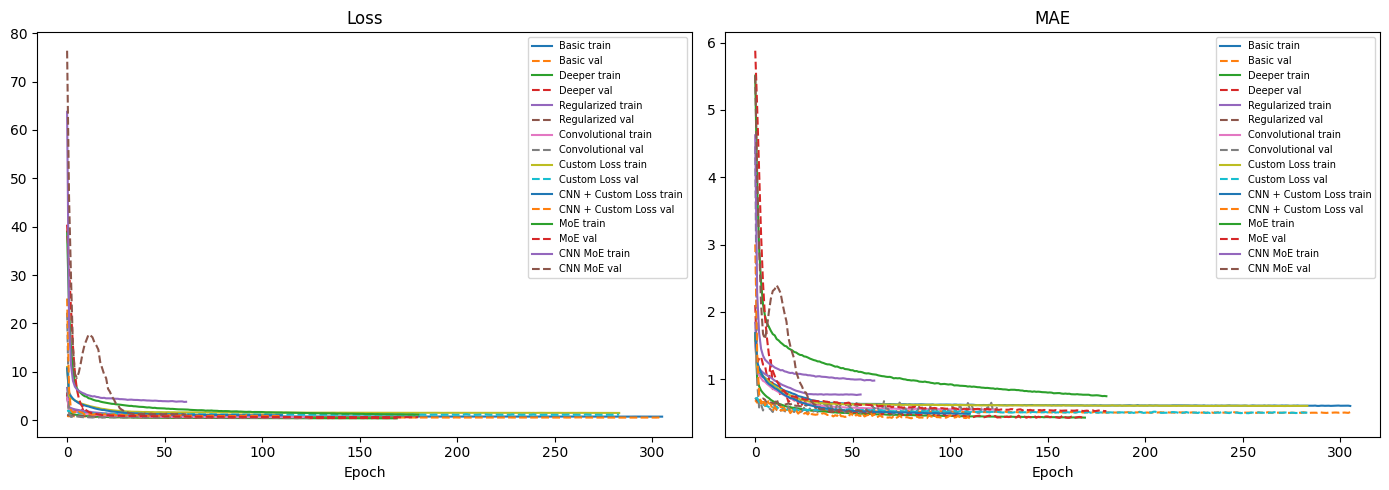

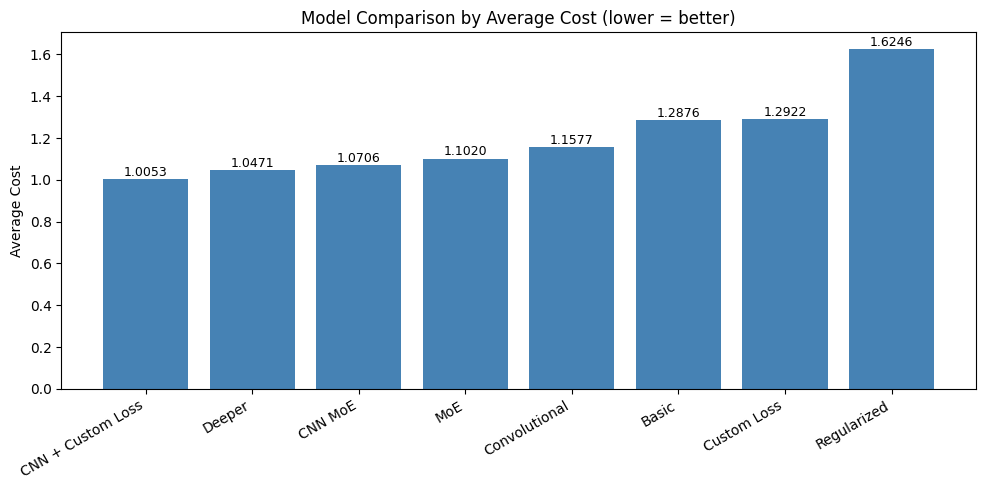

In [19]:
# === Evaluate ALL models using per-group cost ===
# Cost per sample: sigma(y, y_hat) = (log2(y) - log2(y_hat))^2
# Predictions must be >= 1

import matplotlib.pyplot as plt

# ── helpers ──────────────────────────────────────────────────

def get_group_costs(y_pred_log, X_data, y_data):
    """Return dict mapping (k,m) -> avg cost for this model."""
    y_pred = np.exp(y_pred_log)
    y_actual = np.exp(y_data)
    y_pred = np.maximum(y_pred, 1.0)
    cost_per_sample = (np.log2(y_actual) - np.log2(y_pred)) ** 2
    group_costs = {}
    for k_val in [4, 5, 6]:
        for m_val in range(2, 10 - k_val):
            k_idx, m_idx = k_val - 4, m_val - 2
            mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
            if mask.sum() > 0:
                group_costs[(k_val, m_val)] = cost_per_sample[mask].mean()
    return group_costs

# ── Collect predictions & per-group costs for every model ────

all_group_costs = {}

# Single-input models from the results dict
for name, (mdl, hist) in results.items():
    preds = mdl.predict(X_val, verbose=0).flatten()
    all_group_costs[name] = get_group_costs(preds, X_val, y_val)

# MoE (MLP experts)
if 'moe_models' in globals():
    moe_preds = predict_moe(moe_models, X_val)
    all_group_costs['MoE'] = get_group_costs(moe_preds, X_val, y_val)

# CNN MoE (if trained)
if 'cnn_moe_models' in globals():
    cnn_moe_preds = predict_cnn_moe(cnn_moe_models, X_val)
    all_group_costs['CNN MoE'] = get_group_costs(cnn_moe_preds, X_val, y_val)

# ── Detailed per-group cost table ─────────────────────────────

groups = sorted(next(iter(all_group_costs.values())).keys())
model_names = list(all_group_costs.keys())

print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<22}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for name in model_names:
    row = f"{name:<22}"
    for grp in groups:
        row += f"  {all_group_costs[name][grp]:>7.4f}"
    print(row)

# ── Overall cost summary ─────────────────────────────────────

print(f"\n{'=' * 60}")
print(f"  MODEL COMPARISON BY AVERAGE COST (lower = better)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10}")
print("-" * 34)
for name in sorted(model_names, key=lambda n: np.mean(list(all_group_costs[n].values()))):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f}")

best_name = min(model_names, key=lambda n: np.mean(list(all_group_costs[n].values())))
best_cost = np.mean(list(all_group_costs[best_name].values()))
print(f"\n>>> Best model: {best_name}  (avg cost = {best_cost:.6f})")

# ── Plot training curves for all models including MoE ────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single-input models
for name, (mdl, hist) in results.items():
    axes[0].plot(hist.history['loss'], label=f'{name} train')
    axes[0].plot(hist.history['val_loss'], '--', label=f'{name} val')
    axes[1].plot(hist.history['mae'], label=f'{name} train')
    axes[1].plot(hist.history['val_mae'], '--', label=f'{name} val')

# MoE: average loss/mae across the 9 experts per epoch.
def avg_moe_curves(histories):
    """Average training curves across all MoE experts, truncated to min length."""
    all_loss  = [h.history['loss']     for h in histories.values()]
    all_vloss = [h.history['val_loss'] for h in histories.values()]
    all_mae   = [h.history['mae']      for h in histories.values()]
    all_vmae  = [h.history['val_mae']  for h in histories.values()]
    min_len = min(len(x) for x in all_loss)
    all_loss  = [x[:min_len] for x in all_loss]
    all_vloss = [x[:min_len] for x in all_vloss]
    all_mae   = [x[:min_len] for x in all_mae]
    all_vmae  = [x[:min_len] for x in all_vmae]
    return (np.mean(all_loss, axis=0), np.mean(all_vloss, axis=0),
            np.mean(all_mae, axis=0), np.mean(all_vmae, axis=0))

loss, vloss, mae, vmae = avg_moe_curves(moe_histories)
axes[0].plot(loss, label='MoE train')
axes[0].plot(vloss, '--', label='MoE val')
axes[1].plot(mae, label='MoE train')
axes[1].plot(vmae, '--', label='MoE val')

if 'cnn_moe_histories' in globals():
    loss, vloss, mae, vmae = avg_moe_curves(cnn_moe_histories)
    axes[0].plot(loss, label='CNN MoE train')
    axes[0].plot(vloss, '--', label='CNN MoE val')
    axes[1].plot(mae, label='CNN MoE train')
    axes[1].plot(vmae, '--', label='CNN MoE val')

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── Bar chart of average cost per model ──────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
names_sorted = sorted(model_names, key=lambda n: np.mean(list(all_group_costs[n].values())))
costs_sorted = [np.mean(list(all_group_costs[n].values())) for n in names_sorted]
bars = ax2.bar(names_sorted, costs_sorted, color='steelblue')
ax2.set_ylabel('Average Cost')
ax2.set_title('Model Comparison by Average Cost (lower = better)')
for bar, c in zip(bars, costs_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{c:.4f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5 Choose an MOE based on the best models per group.

Hybrid MoE assignment (auto-selected from single-architecture models):
  k=4, m=2 -> CNN + Custom Loss    (cost=0.2254)
  k=4, m=3 -> CNN + Custom Loss    (cost=0.2214)
  k=4, m=4 -> CNN + Custom Loss    (cost=0.4739)
  k=4, m=5 -> CNN + Custom Loss    (cost=2.3500)
  k=5, m=2 -> CNN + Custom Loss    (cost=0.2305)
  k=5, m=3 -> CNN + Custom Loss    (cost=0.4450)
  k=5, m=4 -> Convolutional        (cost=2.5736)
  k=6, m=2 -> CNN + Custom Loss    (cost=0.4463)
  k=6, m=3 -> CNN + Custom Loss    (cost=2.0544)


W0000 00:00:1773515950.079629  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.079837  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.079908  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.080228  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.080666  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.080755  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.080883  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.081043  279567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515950.081162  279567 gp


  MODEL COMPARISON BY AVERAGE COST (lower = better)
Model                    Avg Cost
----------------------------------
Hybrid MoE               1.002291
CNN + Custom Loss        1.005261
Deeper                   1.047141
CNN MoE                  1.070636
MoE                      1.101984
Convolutional            1.157743
Basic                    1.287559
Custom Loss              1.292161
Regularized              1.624585

>>> Best model: Hybrid MoE  (avg cost = 1.002291)


W0000 00:00:1773515951.742577  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.742764  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.742899  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.743209  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.743336  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.743688  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.743845  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.744084  279573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773515951.744420  279573 gp

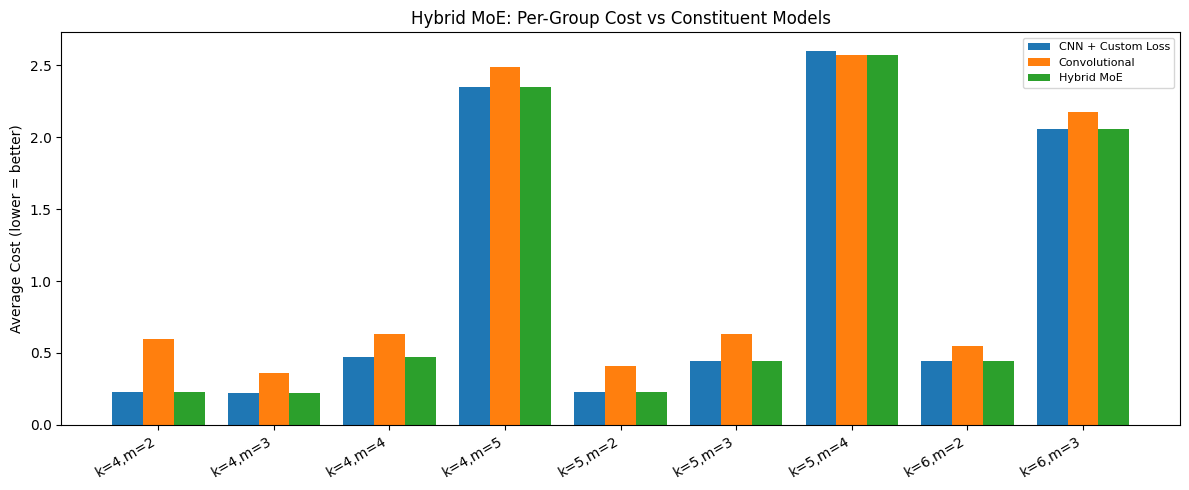

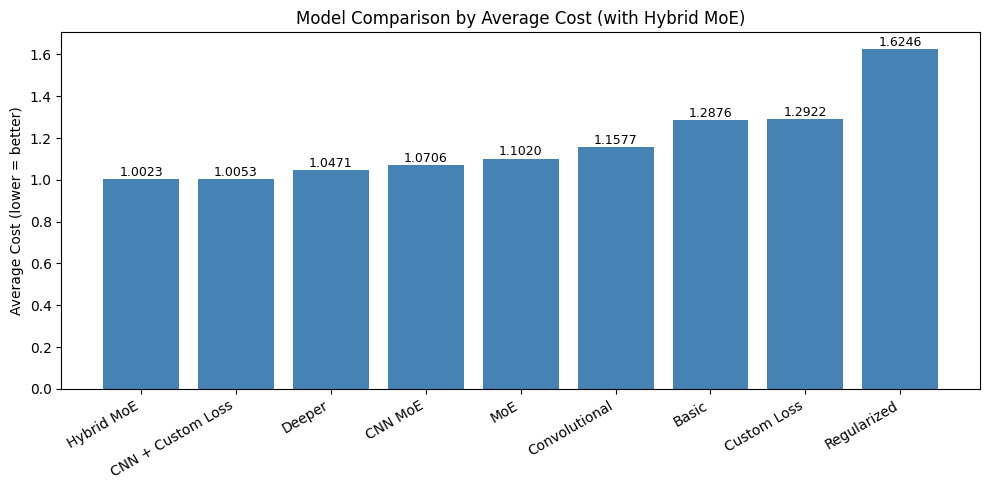

In [20]:
# ── Hybrid MoE: dynamically pick the best model per (k, m) group ──

# Build a prediction lookup: single-architecture models only
# (MoE/CNN MoE already have per-group experts, so mixing them in adds no value)
model_predictors = {}
for name, (mdl, hist) in results.items():
    model_predictors[name] = lambda X, m=mdl: m.predict(X, verbose=0).flatten()

# For each (k,m) group, find the single-architecture model with lowest validation cost
groups = sorted(next(iter(all_group_costs.values())).keys())

best_model_map = {}
print("Hybrid MoE assignment (auto-selected from single-architecture models):")
for grp in groups:
    best_name = min(model_predictors, key=lambda n: all_group_costs[n][grp])
    best_model_map[grp] = (best_name, model_predictors[best_name])
    print(f"  k={grp[0]}, m={grp[1]} -> {best_name:<20s} (cost={all_group_costs[best_name][grp]:.4f})")

# ── Predict with the hybrid MoE ─────────────────────────────
def predict_hybrid_moe(best_model_map, X_data):
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), (_, predictor) in best_model_map.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = predictor(X_data[mask])
    return predictions

hybrid_preds = predict_hybrid_moe(best_model_map, X_val)
all_group_costs['Hybrid MoE'] = get_group_costs(hybrid_preds, X_val, y_val)

# ── Cost summary (with Hybrid MoE) ──────────────────────────
print(f"\n{'=' * 60}")
print(f"  MODEL COMPARISON BY AVERAGE COST (lower = better)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10}")
print("-" * 34)
for name in sorted(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values()))):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f}")

best_name = min(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values())))
print(f"\n>>> Best model: {best_name}  (avg cost = {np.mean(list(all_group_costs[best_name].values())):.6f})")

# ── Plot: Per-group cost comparison (Hybrid MoE vs constituents) ──

import matplotlib.pyplot as plt

groups = sorted(all_group_costs['Hybrid MoE'].keys())
group_labels = [f"k={k},m={m}" for k, m in groups]

# Identify the unique constituent models used by the hybrid
constituent_names = sorted(set(name for name, _ in best_model_map.values()))
plot_models = constituent_names + ['Hybrid MoE']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(groups))
width = 0.8 / len(plot_models)
for i, mname in enumerate(plot_models):
    costs = [all_group_costs[mname][grp] for grp in groups]
    ax.bar(x + i * width, costs, width, label=mname)
ax.set_xticks(x + width * (len(plot_models) - 1) / 2)
ax.set_xticklabels(group_labels, rotation=30, ha='right')
ax.set_ylabel('Average Cost (lower = better)')
ax.set_title('Hybrid MoE: Per-Group Cost vs Constituent Models')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Bar chart of average cost per model (all models) ─────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
names_sorted = sorted(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values())))
costs_sorted = [np.mean(list(all_group_costs[n].values())) for n in names_sorted]
bars = ax2.bar(names_sorted, costs_sorted, color='steelblue')
ax2.set_ylabel('Average Cost (lower = better)')
ax2.set_title('Model Comparison by Average Cost (with Hybrid MoE)')
for bar, c in zip(bars, costs_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{c:.4f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5 Retrain the Hybrid MOE model with the larger dataset and compare again

In [ ]:
# ── Load ALL available datasets ──────────────────────────────
# 1) Professor's original training data (~96K samples)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    prof_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    prof_heights = pickle.load(f)

# 2) HW-4 data (1,042 samples)
with open('/workspace/Homework/Project1/HW-4-n_k_m_P', 'rb') as f:
    rand_data = pickle.load(f)
with open('/workspace/Homework/Project1/HW-4-mHeights', 'rb') as f:
    rand_heights = pickle.load(f)

# 3) Search-generated data (10K diverse samples)
with open('/workspace/Homework/Project1/Search_Generated_n_k_m_P', 'rb') as f:
    search_data = pickle.load(f)
with open('/workspace/Homework/Project1/Search_Generated_m-heights', 'rb') as f:
    search_heights = pickle.load(f)
    
# 3) Search-generated data (10K diverse samples) - version 2    
with open('/workspace/Homework/Project1/Search_Generated_n_k_m_P2', 'rb') as f:
    search_data += pickle.load(f)
with open('/workspace/Homework/Project1/Search_Generated_m-heights2', 'rb') as f:
    search_heights += pickle.load(f)

# Combine all sources
gen_data    = prof_data + rand_data + search_data
gen_heights = list(prof_heights) + list(rand_heights) + list(search_heights)

print(f"Combined dataset: {len(gen_data)} samples")
print(f"  Professor: {len(prof_data)}, HW-4: {len(rand_data)}, Search: {len(search_data)}")

# 80/20 train/val split
gen_train_data, gen_val_data, gen_train_heights, gen_val_heights = train_test_split(
    gen_data, gen_heights, test_size=0.2, random_state=42
)
print(f"Train: {len(gen_train_data)}, Val: {len(gen_val_data)}")

# Preprocess
X_train_gen = preprocess_features(gen_train_data)
y_train_gen = preprocess_labels(gen_train_heights)
X_val_gen   = preprocess_features(gen_val_data)
y_val_gen   = preprocess_labels(gen_val_heights)

print(f"X_train_gen: {X_train_gen.shape}, y_train_gen: {y_train_gen.shape}")
print(f"X_val_gen:   {X_val_gen.shape},   y_val_gen:   {y_val_gen.shape}")

# ── Two-stage training ───────────────────────────────────────
# Stage 1: pre-train on full combined dataset (broad exposure)
# Stage 2: fine-tune on professor's data only (specialize to grading distribution)

EPOCHS_STAGE1   = 500
EPOCHS_STAGE2   = 100
FINETUNE_LR     = 1e-5

stage1_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)

def finetune_on_professor(model, name):
    """Stage 2: lower the learning rate and fine-tune on professor's data only."""
    print(f"\n--- Stage 2: Fine-tuning {name} on professor's data (lr={FINETUNE_LR}) ---")
    keras.backend.set_value(model.optimizer.learning_rate, FINETUNE_LR)
    return model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS_STAGE2, batch_size=BATCH_SIZE, verbose=1,
                     callbacks=[keras.callbacks.EarlyStopping(
                         monitor='val_loss', patience=20,
                         restore_best_weights=True, verbose=1)])

# 1) Deeper model
print("\n" + "=" * 60)
print("Stage 1: Deeper Model on combined data")
print("=" * 60)
deeper_gen = create_deeper_model()
deeper_gen_hist = deeper_gen.fit(X_train_gen, y_train_gen, validation_data=(X_val_gen, y_val_gen),
                                 epochs=EPOCHS_STAGE1, batch_size=BATCH_SIZE, verbose=1, callbacks=[stage1_cb])
deeper_ft_hist = finetune_on_professor(deeper_gen, "Deeper")

# 2) CNN + Custom Loss model
print("\n" + "=" * 60)
print("Stage 1: CNN + Custom Loss Model on combined data")
print("=" * 60)
cnn_custom_gen = create_cnn_custom_loss_model()
cnn_custom_gen_hist = cnn_custom_gen.fit(X_train_gen, y_train_gen, validation_data=(X_val_gen, y_val_gen),
                                          epochs=EPOCHS_STAGE1, batch_size=BATCH_SIZE, verbose=1, callbacks=[stage1_cb])
cnn_ft_hist = finetune_on_professor(cnn_custom_gen, "CNN + Custom Loss")

# 3) Convolutional model
print("\n" + "=" * 60)
print("Stage 1: Convolutional Model on combined data")
print("=" * 60)
conv_gen = create_convolutional_model()
conv_gen_hist = conv_gen.fit(X_train_gen, y_train_gen, validation_data=(X_val_gen, y_val_gen),
                              epochs=EPOCHS_STAGE1, batch_size=BATCH_SIZE, verbose=1, callbacks=[stage1_cb])
conv_ft_hist = finetune_on_professor(conv_gen, "Convolutional")

# ── Assemble the retrained Hybrid MoE ────────────────────────
gen_models = {
    'Deeper':            deeper_gen,
    'CNN + Custom Loss': cnn_custom_gen,
    'Convolutional':     conv_gen,
}

cached_preds = {}
gen_group_costs = {}
for name, mdl in gen_models.items():
    cached_preds[name] = mdl.predict(X_val, verbose=0).flatten()
    gen_group_costs[name] = get_group_costs(cached_preds[name], X_val, y_val)

# Pick best model per (k,m) group and assemble hybrid predictions from cache
groups = sorted(next(iter(gen_group_costs.values())).keys())
hybrid_gen_preds = np.zeros(len(X_val))
print("\nRetrained Hybrid MoE assignment (auto-selected):")
for grp in groups:
    best_name = min(gen_models, key=lambda n: gen_group_costs[n][grp])
    k_idx, m_idx = grp[0] - 4, grp[1] - 2
    mask = (X_val[:, k_idx] == 1) & (X_val[:, 3 + m_idx] == 1)
    hybrid_gen_preds[mask] = cached_preds[best_name][mask]
    print(f"  k={grp[0]}, m={grp[1]} -> {best_name:<20s} (cost={gen_group_costs[best_name][grp]:.4f})")

# ── Evaluate on validation set ──
all_group_costs['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds, X_val, y_val)

# Also evaluate on the generated validation set
cached_preds_gen = {}
for name, mdl in gen_models.items():
    cached_preds_gen[name] = mdl.predict(X_val_gen, verbose=0).flatten()

hybrid_gen_preds_gen = np.zeros(len(X_val_gen))
for grp in groups:
    best_name = min(gen_models, key=lambda n: gen_group_costs[n][grp])
    k_idx, m_idx = grp[0] - 4, grp[1] - 2
    mask = (X_val_gen[:, k_idx] == 1) & (X_val_gen[:, 3 + m_idx] == 1)
    hybrid_gen_preds_gen[mask] = cached_preds_gen[best_name][mask]

all_group_costs_gen = {}
all_group_costs_gen['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds_gen, X_val_gen, y_val_gen)

# ── Cost summary (all models, including retrained hybrid) ────
groups = sorted(next(iter(all_group_costs.values())).keys())
print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<28}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for nm in sorted(all_group_costs.keys()):
    row = f"{nm:<28}"
    for grp in groups:
        row += f"  {all_group_costs[nm][grp]:>7.4f}"
    print(row)

print(f"\n{'=' * 60}")
print(f"  MODEL COMPARISON BY AVERAGE COST (lower = better)")
print(f"{'=' * 60}")
print(f"{'Model':<28} {'Avg Cost':>10}")
print("-" * 40)
for nm in sorted(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values()))):
    avg_c = np.mean(list(all_group_costs[nm].values()))
    print(f"{nm:<28} {avg_c:>10.6f}")

best_name = min(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values())))
print(f"\n>>> Best model: {best_name}  (avg cost = {np.mean(list(all_group_costs[best_name].values())):.6f})")

# ── Plot: Training curves (Stage 1 + Stage 2) ───────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

retrained_hists = {
    'Deeper': deeper_gen_hist,
    'CNN+Custom': cnn_custom_gen_hist,
    'Conv': conv_gen_hist,
}
for label, hist in retrained_hists.items():
    axes[0, 0].plot(hist.history['loss'], label=f'{label} train')
    axes[0, 0].plot(hist.history['val_loss'], '--', label=f'{label} val')
    axes[0, 1].plot(hist.history['mae'], label=f'{label} train')
    axes[0, 1].plot(hist.history['val_mae'], '--', label=f'{label} val')
axes[0, 0].set_title('Stage 1 (Combined Data) - Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 1].set_title('Stage 1 (Combined Data) - MAE')
axes[0, 1].legend(fontsize=8)

ft_hists = {
    'Deeper': deeper_ft_hist,
    'CNN+Custom': cnn_ft_hist,
    'Conv': conv_ft_hist,
}
for label, hist in ft_hists.items():
    axes[1, 0].plot(hist.history['loss'], label=f'{label} train')
    axes[1, 0].plot(hist.history['val_loss'], '--', label=f'{label} val')
    axes[1, 1].plot(hist.history['mae'], label=f'{label} train')
    axes[1, 1].plot(hist.history['val_mae'], '--', label=f'{label} val')
axes[1, 0].set_title("Stage 2 (Fine-tune on Professor's Data) - Loss")
axes[1, 0].legend(fontsize=8)
axes[1, 1].set_title("Stage 2 (Fine-tune on Professor's Data) - MAE")
axes[1, 1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ── Plot: Per-group cost - Original Hybrid MoE vs Retrained ──

group_labels = [f"k={k},m={m}" for k, m in groups]
fig2, ax2 = plt.subplots(figsize=(12, 5))
x = np.arange(len(groups))
width = 0.35
orig_costs = [all_group_costs['Hybrid MoE'][grp] for grp in groups]
retrained_costs = [all_group_costs['Hybrid MoE (retrained)'][grp] for grp in groups]
ax2.bar(x - width/2, orig_costs, width, label='Hybrid MoE (original)')
ax2.bar(x + width/2, retrained_costs, width, label='Hybrid MoE (retrained)')
ax2.set_xticks(x)
ax2.set_xticklabels(group_labels, rotation=30, ha='right')
ax2.set_ylabel('Average Cost (lower = better)')
ax2.set_title('Per-Group Cost: Original vs Retrained Hybrid MoE')
ax2.legend()
plt.tight_layout()
plt.show()

# ── Bar chart of average cost per model (all models) ─────────
fig3, ax3 = plt.subplots(figsize=(12, 5))
names_sorted = sorted(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values())))
costs_sorted = [np.mean(list(all_group_costs[n].values())) for n in names_sorted]
bars = ax3.bar(names_sorted, costs_sorted, color='steelblue')
ax3.set_ylabel('Average Cost (lower = better)')
ax3.set_title('Model Comparison by Average Cost (All Models)')
for bar, c in zip(bars, costs_sorted):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{c:.4f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Combined dataset: 296396 samples
  Professor: 96524, HW-4: 1042, Search: 198830
Train: 237116, Val: 59280
X_train_gen: (237116, 37), y_train_gen: (237116,)
X_val_gen:   (59280, 37),   y_val_gen:   (59280,)

Stage 1: Deeper Model on combined data
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/927 [..............................] - ETA: 36:30 - loss: 44.5929 - mae: 6.3089

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

927/927 [==============================] - 17s 16ms/step - loss: 2.3955 - mae: 1.1139 - val_loss: 2.8481 - val_mae: 1.4679
Epoch 2/500
927/927 [==============================] - 14s 15ms/step - loss: 1.1194 - mae: 0.7929 - val_loss: 3.3964 - val_mae: 1.6150
Epoch 3/500
927/927 [==============================] - 14s 15ms/step - loss: 0.8991 - mae: 0.6991 - val_loss: 2.1362 - val_mae: 1.1891
Epoch 4/500
927/927 [==============================] - 15s 16ms/step - loss: 0.8019 - mae: 0.6514 - val_loss: 2.0547 - val_mae: 1.1151
Epoch 5/500
927/927 [==============================] - 14s 15ms/step - loss: 0.7400 - mae: 0.6204 - val_loss: 1.5752 - val_mae: 0.9273
Epoch 6/500
927/927 [==============================] - 14s 15ms/step - loss: 0.7064 - mae: 0.6000 - val_loss: 1.2651 - val_mae: 0.8021
Epoch 7/500
927/927 [==============================] - 14s 15ms/step - loss: 0.6735 - mae: 0.5822 - val_loss: 1.2638 - val_mae: 0.7864
Epoch 8/500
927/927 [==============================] - 14s 16ms/ste

Error: KeyboardInterrupt: 
[0;31m---------------------------------------------------------------------------[0m
[0;31mKeyboardInterrupt[0m                         Traceback (most recent call last)
Cell [0;32mIn[21], line 73[0m
[1;32m     71[0m [38;5;28mprint[39m([38;5;124m"[39m[38;5;124m=[39m[38;5;124m"[39m [38;5;241m*[39m [38;5;241m60[39m)
[1;32m     72[0m deeper_gen [38;5;241m=[39m create_deeper_model()
[0;32m---> 73[0m deeper_gen_hist [38;5;241m=[39m [43mdeeper_gen[49m[38;5;241;43m.[39;49m[43mfit[49m[43m([49m[43mX_train_gen[49m[43m,[49m[43m [49m[43my_train_gen[49m[43m,[49m[43m [49m[43mvalidation_data[49m[38;5;241;43m=[39;49m[43m([49m[43mX_val_gen[49m[43m,[49m[43m [49m[43my_val_gen[49m[43m)[49m[43m,[49m
[1;32m     74[0m [43m                                 [49m[43mepochs[49m[38;5;241;43m=[39;49m[43mEPOCHS_STAGE1[49m[43m,[49m[43m [49m[43mbatch_size[49m[38;5;241;43m=[39;49m[43mBATCH_SIZE[49m[43m,[49

In [ ]:
# Quick diagnostic: print costs and generated dataset sizes
print("=== AVERAGE COST (all models, lower = better) ===")
for nm in sorted(all_group_costs, key=lambda n: np.mean(list(all_group_costs[n].values()))):
    avg_c = np.mean(list(all_group_costs[nm].values()))
    print(f"  {nm:<28} cost={avg_c:.6f}")

print(f"\nOriginal dataset: train={len(X_train)}, val={len(X_val)}")
print(f"Generated dataset: train={len(X_train_gen)}, val={len(X_val_gen)}")

# Check: how many epochs did each retrained model actually run?
print(f"\nRetrained Deeper: {len(deeper_gen_hist.history['loss'])} epochs")
print(f"Retrained CNN+Custom: {len(cnn_custom_gen_hist.history['loss'])} epochs")
print(f"Retrained Conv: {len(conv_gen_hist.history['loss'])} epochs")

# Final train/val loss for retrained models
print(f"\nRetrained Deeper     - train_loss: {deeper_gen_hist.history['loss'][-1]:.4f}, val_loss: {deeper_gen_hist.history['val_loss'][-1]:.4f}")
print(f"Retrained CNN+Custom - train_loss: {cnn_custom_gen_hist.history['loss'][-1]:.4f}, val_loss: {cnn_custom_gen_hist.history['val_loss'][-1]:.4f}")
print(f"Retrained Conv       - train_loss: {conv_gen_hist.history['loss'][-1]:.4f}, val_loss: {conv_gen_hist.history['val_loss'][-1]:.4f}")

# Compare: retrained hybrid on ORIGINAL val vs generated val
print(f"\nHybrid MoE (retrained) on ORIGINAL val:")
for grp in sorted(all_group_costs['Hybrid MoE (retrained)'].keys()):
    print(f"  {grp}: {all_group_costs['Hybrid MoE (retrained)'][grp]:.6f}")

print(f"\nHybrid MoE (retrained) on GENERATED val:")
for grp in sorted(all_group_costs_gen['Hybrid MoE (retrained)'].keys()):
    print(f"  {grp}: {all_group_costs_gen['Hybrid MoE (retrained)'][grp]:.6f}")

# Compare original Hybrid MoE vs retrained
if 'Hybrid MoE' in all_group_costs:
    print(f"\nOriginal Hybrid MoE on ORIGINAL val:")
    for grp in sorted(all_group_costs['Hybrid MoE'].keys()):
        print(f"  {grp}: {all_group_costs['Hybrid MoE'][grp]:.6f}")